<span style="color:Blue">

# ROAD SEGMENTATION

</span>

In [122]:
"""
Fragment to try on : 
# 11545_sat
# 14361_sat
# 4227_sat
# 5279_sat
# 17193_sat
"""


'\nFragment to try on : \n# 11545_sat\n# 14361_sat\n# 4227_sat\n# 5279_sat\n# 17193_sat\n'

OpenCV-based approaches rely on handcrafted rules like color thresholds, edge detection, and morphology. These methods work only when the visual properties of roads are consistent. However, in real-world scenarios, road appearance varies significantly due to lighting, shadows, materials, occlusions, and different imaging conditions.

Because OpenCV does not learn from data, it cannot generalize across such variations. In contrast, deep learning models like U-Net learn hierarchical features from large datasets, allowing them to adapt to diverse road appearances and achieve better generalization

# U-NET Architecture for Road_Segmentation 

U-Net is specifically designed for pixel-wise segmentation tasks. It combines downsampling to capture global context and upsampling with skip connections to recover spatial details. This makes it especially suitable for road segmentation, where both the overall structure and fine boundaries are important

Why not classical ML ??

Classical machine learning methods rely on manually engineered features such as color, texture, or edges. These features are often insufficient to capture the complex and varying structure of roads in real-world images. Additionally, classical models lack spatial awareness, which is crucial for segmentation tasks. Deep learning models like U-Net automatically learn hierarchical and spatial features, making them more suitable

### Goal
This implements a deep learning based pipeline for extracting roads from stitched image / satellite image using  a U-Net architecture.

The objective is to perform **pixel-wise binary segmentation**, where each pixel is classified as either:
- Road (1)
- Background (0)

### Flow
- U-Net is based on encoder-decoder architecture  
- Combination of Dice Loss and BCE Loss for class imbalance  
- Data augmentation for improved generalization  
- Post-processing for noise removal and structure refinement  
- Evaluation on unseen test images  

In [1]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F 

## Dataset Preparation

I used the DeepGlobe Road Extraction Dataset for training where:
- Input: Satellite images (_sat.jpg)
- Target: Binary road masks (_mask.png)

### Preprocessing Steps:
- Resize images for faster training
- Normalize pixel values
- Convert masks to binary format
- Apply random augmentations (flip)
- Slight dilation to enhance thin roads

In [ ]:
class DeepGlobeDataset(Dataset):
    def __init__(self, root_dir, img_size=128, limit=None):
        self.root_dir = root_dir
        self.img_size = img_size

        self.images = [f for f in os.listdir(root_dir) if f.endswith('_sat.jpg')]

        if limit:
            self.images = self.images[:limit]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.root_dir, img_name)
        mask_path = os.path.join(self.root_dir, img_name.replace('_sat.jpg', '_mask.png'))

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, 0)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size))

        # Normalize
        image = image / 255.0
        image = (image - 0.5) / 0.5

        # Binary mask
        mask = (mask > 127).astype(np.float32)

        # Augment
        if np.random.rand() > 0.5:
            image = np.fliplr(image).copy()
            mask = np.fliplr(mask).copy()

        if np.random.rand() > 0.5:
            image = np.flipud(image).copy()
            mask = np.flipud(mask).copy()

        # TO TENSOR
        image = torch.tensor(image, dtype=torch.float32).permute(2,0,1)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask

## U-Net Architecture

### Encoder (Downsampling)
- Extracts high-level features
- Captures global context

### Decoder (Upsampling)
- Recovers spatial resolution
- Produces pixel-wise predictions

### Skip Connections
- Preserve fine-grained details
- Help in detecting thin structures like roads



In [97]:
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))

        b = self.bottleneck(self.pool3(d3))

        u3 = self.up3(b)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.final(u1)  # logits

## Loss Function
Road segmentation generally suffers from **class imbalance** (few road pixels in large background).
To address this, we combine:

### Dice Loss
- Focuses on overlap between prediction and ground truth
- Improves segmentation quality

### Focal Loss
- Focuses on hard-to-classify pixels
- Reduces impact of easy negatives

### Final Loss:
Loss = Dice Loss + Focal Loss

In [98]:
import torch.nn.functional as F

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-6

    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)


bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([3.0]).to(device))

def loss_fn(pred, target):
    return bce(pred, target) + dice_loss(pred, target)

## Model Training

- Optimizer: Adam  
- Learning Rate: 1e-4  
- Batch Size: 4  
- Epochs: 15  

### Training Process:
- Forward pass → prediction
- Compute loss
- Backpropagation
- Weight update

All while monitor:
- Loss reduction
- Prediction behavior (mean output)

In [99]:
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = DeepGlobeDataset("DeepGlobe_Dataset/train", img_size=128, limit=1200)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 15

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 1.3876
Epoch 2, Loss: 1.2250
Epoch 3, Loss: 1.1281
Epoch 4, Loss: 1.0573
Epoch 5, Loss: 1.0001
Epoch 6, Loss: 0.9499
Epoch 7, Loss: 0.9086
Epoch 8, Loss: 0.8794
Epoch 9, Loss: 0.8404
Epoch 10, Loss: 0.8279
Epoch 11, Loss: 0.8030
Epoch 12, Loss: 0.7877
Epoch 13, Loss: 0.7759
Epoch 14, Loss: 0.7627
Epoch 15, Loss: 0.7500


## Prediction

1. Apply sigmoid activation
2. Convert to binary mask using threshold (0.5)
3. Overlay prediction on original image

In [108]:
model.eval()

img, gt = dataset[25]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))
    pred = torch.sigmoid(pred)

pred_mask = pred.squeeze().cpu().numpy()

# IMPORTANT: fixed threshold
pred_bin = (pred_mask > 0.5).astype(np.uint8)

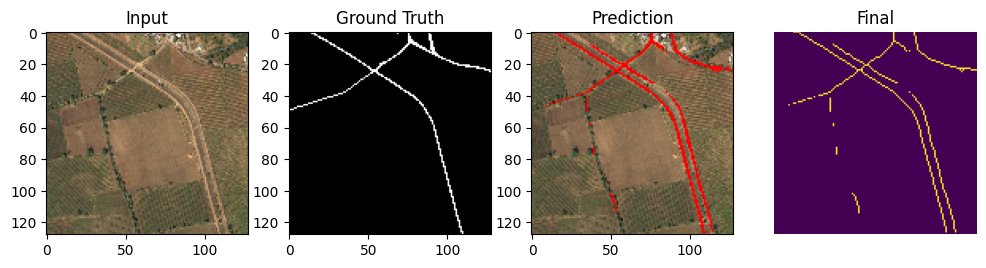

In [109]:
img_np = img.permute(1,2,0).numpy()
img_np = (img_np * 0.5 + 0.5)  # unnormalize

overlay = img_np.copy()
overlay[pred_bin == 1] = [1, 0, 0]

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img_np)
plt.title("Input")

plt.subplot(1,4,2)
plt.imshow(gt.squeeze(), cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,4,3)
plt.imshow(overlay)
plt.title("Prediction")

from skimage.morphology import skeletonize

pred_bin = skeletonize(pred_bin).astype(np.uint8)

plt.subplot(1,4,4)
plt.imshow(pred_bin)
plt.title("Final")
plt.axis("off")

plt.show()

In [110]:
torch.save(model.state_dict(), "road_unet_final.pth")
print("Model v2 saved")

Model v2 saved


## Testing on Deepglobe dataset 

In [115]:
class DeepGlobeTestDataset(Dataset):
    def __init__(self, root_dir, img_size=128):
        self.root_dir = root_dir
        self.img_size = img_size
        self.images = [f for f in os.listdir(root_dir) if f.endswith('_sat.jpg')]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.root_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, (self.img_size, self.img_size))

        image = image / 255.0
        image = (image - 0.5) / 0.5

        image_tensor = torch.tensor(image, dtype=torch.float32).permute(2,0,1)

        return image_tensor, img_name

In [116]:
test_dataset = DeepGlobeTestDataset("DeepGlobe_Dataset/test", img_size=128)

In [117]:
model = UNet().to(device)
model.load_state_dict(torch.load("road_unet_final.pth", map_location=device))
model.eval()

UNet(
  (down1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (net): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )


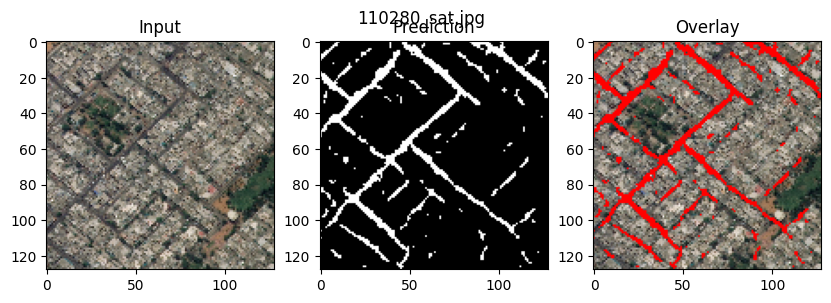

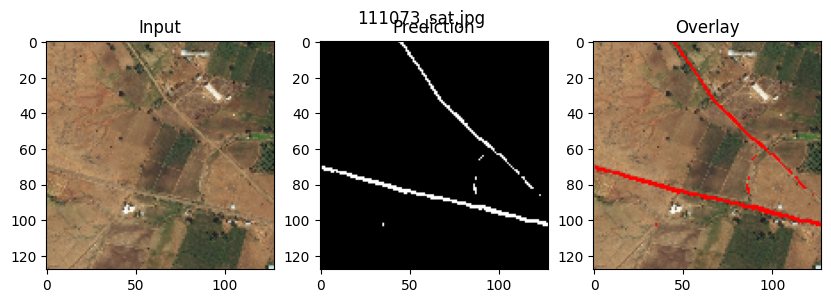

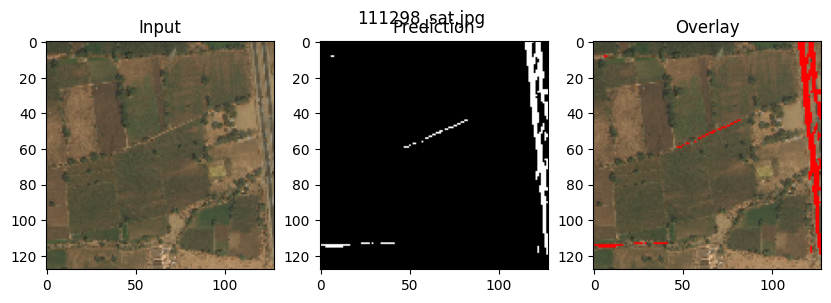

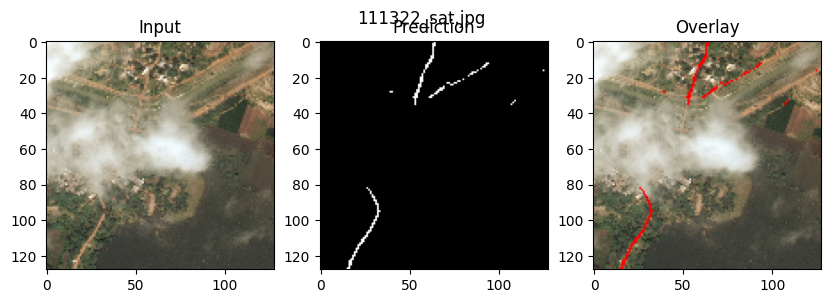

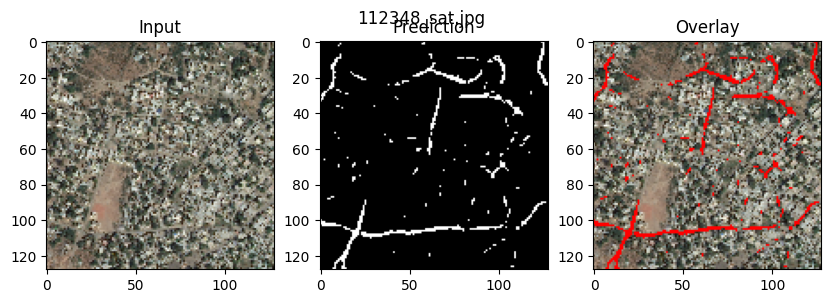

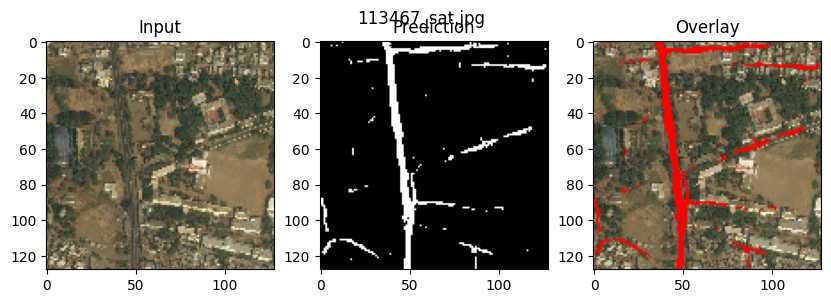

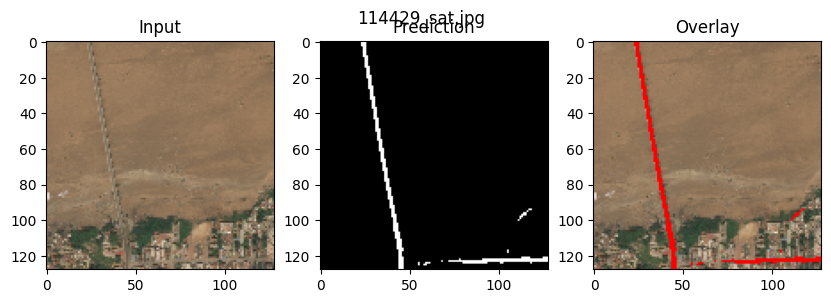

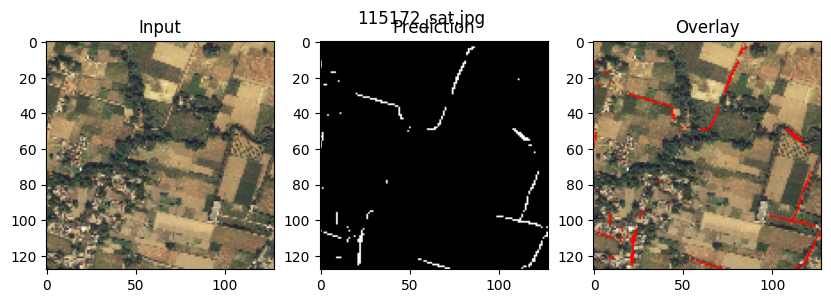

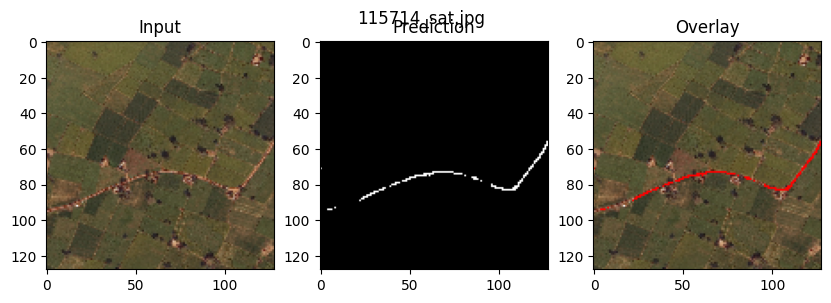

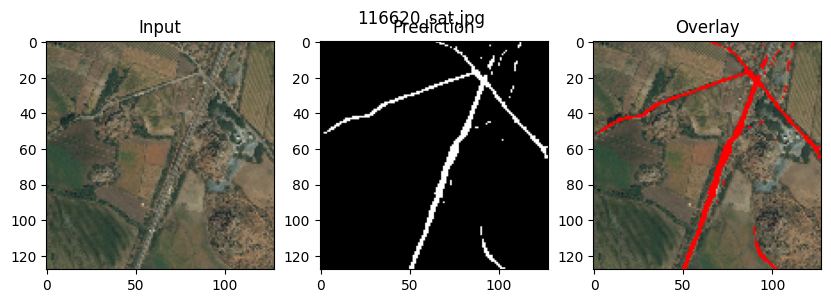

In [120]:
import matplotlib.pyplot as plt

for i in range(10,20):   # just first 5 images
    img, name = test_dataset[i]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        pred = torch.sigmoid(pred)

    pred_mask = pred.squeeze().cpu().numpy()
    pred_bin = (pred_mask > 0.5).astype(np.uint8)

    # unnormalize image
    img_np = img.permute(1,2,0).numpy()
    img_np = (img_np * 0.5 + 0.5)

    overlay = img_np.copy()
    overlay[pred_bin == 1] = [1, 0, 0]

    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(img_np)
    plt.title("Input")

    plt.subplot(1,3,2)
    plt.imshow(pred_bin, cmap='gray')
    plt.title("Prediction")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Overlay")

    plt.suptitle(name)
    plt.show()

##  Post-Processing

Raw predictions may sometimes contain noise and fragmented roads.

### Improvements:
- Remove small connected components (noise)
- Morphological closing (connect broken roads)
- Skeletonization (thin centerlines)


<span style="color:Red">

# Implementation on Task image 

</span>

In [ ]:
import cv2
import numpy as np
import torch
from skimage.morphology import skeletonize

def predict_single_image(img_path, model, device, img_size=128):
    
    # LOAD IMAGE
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    original = img.copy()

    # PREPROCESS 
    img_resized = cv2.resize(img, (img_size, img_size))
    img_norm = img_resized / 255.0
    img_norm = (img_norm - 0.5) / 0.5

    tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2,0,1)
    tensor = tensor.unsqueeze(0).to(device)

    # PREDICT 
    with torch.no_grad():
        pred = model(tensor)
        pred = torch.sigmoid(pred)

    pred_mask = pred.squeeze().cpu().numpy()

    #THRESHOLD 
    pred_bin = (pred_mask > 0.5).astype(np.uint8)

    # POST-PROCESS 
    # remove small noise
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(pred_bin)
    clean = np.zeros_like(pred_bin)

    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] > 50:
            clean[labels == i] = 1

    # morphology
    kernel = np.ones((3,3), np.uint8)
    clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)

    # skeleton (optional but nice)
    clean = skeletonize(clean).astype(np.uint8)

    # RESIZE BACK 
    clean = cv2.resize(clean, (original.shape[1], original.shape[0]))

    # OVERLAY 
    overlay = original.copy() / 255.0
    overlay[clean == 1] = [1, 0, 0]

    return original, clean, overlay

In [ ]:
img_path = "output/your_image.jpg"

orig, mask, overlay = predict_single_image(img_path, model, device)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(orig)
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Prediction")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")

plt.show()

In [ ]:
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(pred_bin)

clean = np.zeros_like(pred_bin)

for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] > 50:   # tune: 50–150
        clean[labels == i] = 1

In [ ]:
kernel = np.ones((3,3), np.uint8)
clean = cv2.morphologyEx(pred_bin, cv2.MORPH_OPEN, kernel)

The model achieves good structural detection of roads, especially thin and curved ones, but can confuse similar linear patterns. This is a known limitation of data-driven segmentation without additional contextual constraints

In [123]:
output_dir = "output/"

In [ ]:
cv2.imwrite(os.path.join(output_dir, "Road_mask.png"), mask)
cv2.imwrite(os.path.join(output_dir, "Road_overlay.png"), overlay)